# News Summarization Service

A reproducible walkthrough of pretrained DistilBART inference, a local FastAPI demo, and evaluation on 500 CNN/DailyMail 3.0.0 test articles.

**Scope:** English pasted text; no training, fine-tuning, URL scraping, or deployment. Reusable implementation is in `src/news_summarization/`. This notebook uses the same implementation as the service.

Run all cells with **Python (News Summarization)** after following the README. The notebook performs real inference on one synthetic article and a long-input variant, tests the API, and reads the saved full evaluation. It does not rerun the 500-article benchmark automatically.

In [1]:
from pathlib import Path
import json
import sys
import pandas as pd
import torch
from IPython.display import display, Markdown, Image
from news_summarization.config import ROOT, DATA_DIR, REPORTS_DIR, MODEL_ID
from news_summarization.preprocessing import clean_article
from news_summarization.summarizer import Summarizer

print('Project:', ROOT)
print('Python:', sys.version.split()[0])
print('PyTorch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
print('Device:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')

C:\Users\Shasaank\study isle\Vista tech\Projects\NEWS Summarization service\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project: C:\Users\Shasaank\study isle\Vista tech\Projects\NEWS Summarization service
Python: 3.11.17
PyTorch: 2.11.0+cu128
CUDA available: True
Device: NVIDIA GeForce RTX 4060 Laptop GPU


## 1. Dataset and reproducibility

The test split contains 11,490 article/highlight pairs. A fixed random sample of 500 is selected without replacement with seed 42. Human highlights are references only and never inputs to generation. The selected model is already trained for CNN/DailyMail summarization; this project evaluates inference without further training.

In [2]:
manifest = json.loads((DATA_DIR / 'evaluation_manifest.json').read_text(encoding='utf-8'))
model_manifest = json.loads((ROOT / 'models' / 'model_manifest.json').read_text(encoding='utf-8'))
records = [json.loads(line) for line in (DATA_DIR / 'processed' / 'evaluation.jsonl').read_text(encoding='utf-8').splitlines()]
assert len(records) == 500
assert [r['id'] for r in records] == manifest['ids']
assert len(set(manifest['ids'])) == 500
print('Dataset revision:', manifest['revision'])
print('Model revision:', model_manifest['revision'])
print('Sample size / population:', manifest['sample_size'], '/', manifest['population_size'])
lengths = pd.DataFrame({'article_words': [len(r['article'].split()) for r in records], 'reference_words': [len(r['highlights'].split()) for r in records]})
display(lengths.describe().round(1))

Dataset revision: 96df5e686bee6baa90b8bee7c28b81fa3fa6223d
Model revision: a4f8f3ea906ed274767e9906dbaede7531d660ff
Sample size / population: 500 / 11490


,article_words,reference_words
count,500.0,500.0
mean,676.9,54.1
std,334.6,19.1
min,148.0,15.0
25%,426.0,40.0
50%,625.5,51.0
75%,858.5,62.0
max,1827.0,128.0


## 2. Preprocessing

Normalize Unicode, decode HTML entities, remove invisible controls, and collapse whitespace. Preserve punctuation and capitalization. Inputs require 20 words and are limited to 100,000 characters. The tokenizer subsequently keeps at most 1,024 tokens, including special tokens.

In [3]:
demo_article = (
    "The city council opened a new public library on Monday. The building includes reading rooms, "
    "computers, and a children's section. Residents can borrow books for free. Officials said "
    "the library will open six days a week and offer classes beginning next month."
)
print(clean_article(demo_article.replace('city council', 'city\t council')))
try:
    clean_article('Too short.')
except ValueError as error:
    print('Expected validation error:', error)

The city council opened a new public library on Monday. The building includes reading rooms, computers, and a children's section. Residents can borrow books for free. Officials said the library will open six days a week and offer classes beginning next month.
Expected validation error: Enter an article containing at least 20 words.


## 3. Real abstractive inference

DistilBART has 12 encoder and 6 decoder layers (about 306M parameters). Load the pinned checkpoint locally, use GPU half precision when CUDA is available, and otherwise use CPU float32. Beam search uses four beams with sampling disabled. Token limits control generation length rather than exact word counts.

In [4]:
engine = Summarizer()
result = engine.summarize(demo_article)
print('SOURCE:', demo_article)
print('\nGENERATED:', result.summary)
display(pd.DataFrame([{k: v for k, v in result.to_dict().items() if k != 'summary'}]))

SOURCE: The city council opened a new public library on Monday. The building includes reading rooms, computers, and a children's section. Residents can borrow books for free. Officials said the library will open six days a week and offer classes beginning next month.

GENERATED: The building includes reading rooms, computers, and a children's section . Officials said the library will open six days a week and offer classes beginning next month .


,model,device,input_tokens,used_input_tokens,truncated,output_tokens,elapsed_seconds
0,sshleifer/distilbart-cnn-12-6,cuda,51,51,False,31,0.7106


## 4. Long-article handling

The service returns both original and used input token counts and an explicit truncation flag. Summaries may omit information beyond the retained prefix; the service does not claim to summarize an entire overlong article.

In [5]:
long_result = engine.summarize(demo_article * 30)
assert long_result.truncated and long_result.used_input_tokens == 1024
print('Original tokens:', long_result.input_tokens)
print('Used tokens:', long_result.used_input_tokens)
print('Truncated:', long_result.truncated)
print('Summary:', long_result.summary)

Token indices sequence length is longer than the specified maximum sequence length for this model (1472 > 1024). Running this sequence through the model will result in indexing errors


Original tokens: 1472
Used tokens: 1024
Truncated: True
Summary: The city council opened a new public library on Monday. The building includes reading rooms, computers, and a children's section. Residents can borrow books for free. Officials said the library will open six days a week and offer classes beginning next month .


## 5. API demonstration

The same loaded model is exercised through FastAPI's actual routes with a test client. To use the interactive browser demo, run `python -m uvicorn news_summarization.api:app --host 127.0.0.1 --port 8000` and open `http://127.0.0.1:8000/docs`.

In [6]:
from fastapi.testclient import TestClient
from news_summarization.api import create_app

with TestClient(create_app(lambda: engine)) as client:
    print('Health:', client.get('/health').json())
    response = client.post('/summarize', json={'article': demo_article})
    assert response.status_code == 200
    display(response.json())
    invalid = client.post('/summarize', json={'article': 'Too short.'})
    assert invalid.status_code == 422
    print('Invalid input status:', invalid.status_code)

C:\Users\Shasaank\study isle\Vista tech\Projects\NEWS Summarization service\.venv\Lib\site-packages\fastapi\testclient.py:1: StarletteDeprecationWarning: Using `httpx` with `starlette.testclient` is deprecated; install `httpx2` instead.
  from starlette.testclient import TestClient as TestClient  # noqa


Health: {'status': 'ready', 'model': 'sshleifer/distilbart-cnn-12-6', 'device': 'cuda'}


{'summary': "The building includes reading rooms, computers, and a children's section . Officials said the library will open six days a week and offer classes beginning next month .",
 'model': 'sshleifer/distilbart-cnn-12-6',
 'device': 'cuda',
 'input_tokens': 51,
 'used_input_tokens': 51,
 'truncated': False,
 'output_tokens': 31,
 'elapsed_seconds': 0.3056}

Invalid input status: 422


## 6. Held-out evaluation results

The complete benchmark was run using `python -m news_summarization.evaluate`. Scores below are measured macro-average ROUGE F1 on a 0–100 scale, with Porter stemming. ROUGE-L uses longest common subsequence, not ROUGE-Lsum. Bootstrap intervals use 2,000 article-level resamples. Saved results are loaded rather than recomputed during this walkthrough.

,mean_f1,bootstrap_95_ci
rouge1,44.6571,"[43.6595, 45.6742]"
rouge2,21.0311,"[20.013, 22.1333]"
rougeL,30.8824,"[29.9063, 31.9666]"


Truncated articles: 142
Latency (seconds): {'mean': 0.8592, 'median': 0.8105, 'p95': 1.3372, 'total_inference': 429.6231, 'latest_run_wall_time_excluding_load_and_warmup': 430.9556}


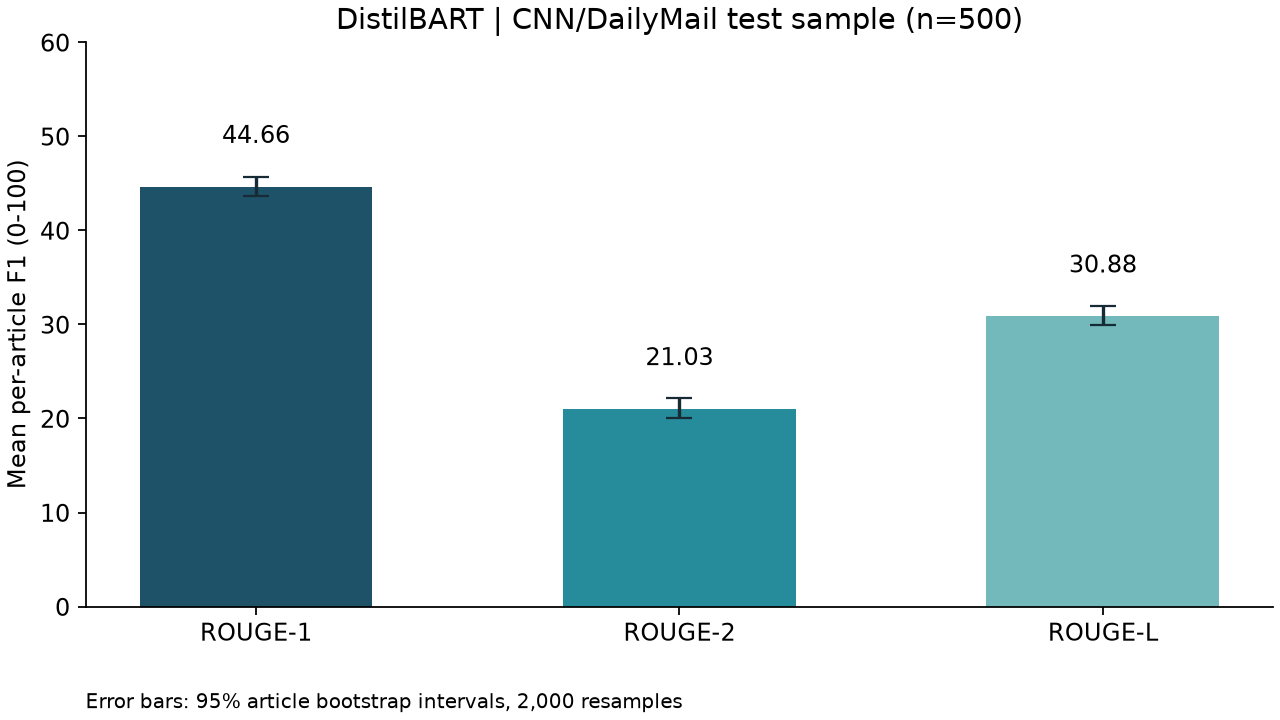

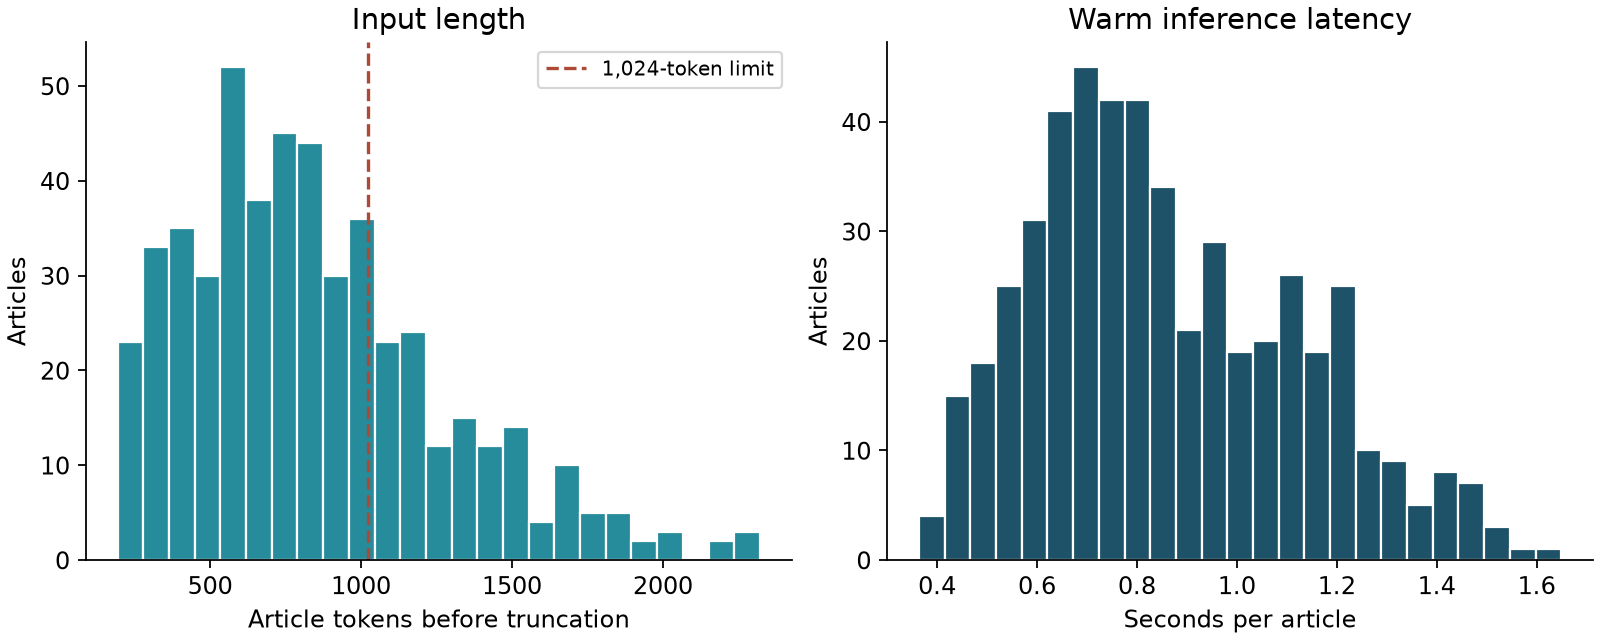

In [7]:
metrics = json.loads((REPORTS_DIR / 'metrics.json').read_text(encoding='utf-8'))
predictions = [json.loads(line) for line in (REPORTS_DIR / 'predictions.jsonl').read_text(encoding='utf-8').splitlines()]
assert len(predictions) == metrics['sample_size'] == 500
assert [r['id'] for r in predictions] == manifest['ids']
display(pd.DataFrame(metrics['scores']).T)
print('Truncated articles:', metrics['truncated_articles'])
print('Latency (seconds):', metrics['latency_seconds'])
display(Image(filename=str(REPORTS_DIR / 'figures' / 'rouge_scores.png')))
display(Image(filename=str(REPORTS_DIR / 'figures' / 'input_lengths_and_latency.png')))

## 7. Reference versus generated summary

This is the first randomly selected test article, not an example chosen for a high score. Full inputs and five examples are in `reports/sample_summaries.md` and `.json`.

In [8]:
sample = json.loads((REPORTS_DIR / 'sample_summaries.json').read_text(encoding='utf-8'))[0]
print('Dataset ID:', sample['id'])
print('\nARTICLE:\n', sample['article'])
print('\nHUMAN REFERENCE:\n', sample['reference'])
print('\nGENERATED SUMMARY:\n', sample['summary'])
print('\nROUGE:', sample['scores'])

Dataset ID: a10fd75e110ddf8b5d2a283b9ba65e204808d669

ARTICLE:
 For former Ole Miss star Marshall Henderson, revenge is a dish best served cold. The ex-college player was mocked for his alleged drug use by Erin Andrews on Twitter two years ago. But he has had the last laugh, after he jumped on revelations the TV reporter's boyfriend, Los Angeles Kings player Jarret Stoll, was busted in Las Vegas last week, accused of tying to smuggle cocaine and MDMA, or 'molly', into the MGM Grand hotel. He tweeted  the former Dancing With The Stars contestant on Monday saying: 'lol wassup with your boyfriend.' Revenge: Former Ole Miss star Marshall Henderson jumped on the revelations Jarret Stoll (right) was arrested in a drugs bust last week by tweeting to Erin Andrews: 'lol wassup with your boyfriend.' He was suspended in 2013 for allegedly failing a drugs test. Andrews responded to the news then by saying: 'He mocking anyone now?' She was referencing his reputation of being a hothead and badmouthi

## 8. Interpretation and learnings

- Abstractive models generate new wording; extractive methods select existing sentences. This project implements the abstractive approach.
- ROUGE measures lexical overlap, not truth or completeness. Compare generated claims with the article; a fluent summary can still be wrong.
- Truncation discards the article tail. References remain complete during evaluation, so scores reflect this limitation.
- These 500 in-domain test articles are a sample, not the complete benchmark. The older English publisher mix limits generalization.
- Revisions, IDs, checksums, configuration, package versions, and per-article outputs make the experiment auditable. Exact cross-device output equality is not guaranteed.

See `reports/project_report.md`, `reports/evaluation_report.md`, and `reports/qualitative_review.md` for detailed findings.

### References

- [CNN/DailyMail dataset](https://huggingface.co/datasets/abisee/cnn_dailymail)
- [DistilBART checkpoint](https://huggingface.co/sshleifer/distilbart-cnn-12-6)
- [BART paper](https://aclanthology.org/2020.acl-main.703/)
- [ROUGE implementation](https://github.com/google-research/google-research/tree/master/rouge)